# SMS Spam Detection Using Natural Language Processing

**NLP Assignment**

This project classifies SMS messages as **Spam** or **Ham (Not Spam)** using text preprocessing, TF-IDF, and Multinomial Naive Bayes.

**Important:** The notebook saves the trained model to `models/sms_spam_model.pkl`. The web app loads that **same model file**, so the notebook and app are connected.

In [3]:
!pip install -q nltk scikit-learn pandas matplotlib joblib gradio


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import nltk


from pathlib import Path
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [5]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\os\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\os\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\os\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\os\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\os\AppData\Roaming\nltk_data...


True

## 1. Load the dataset

In [6]:
DATA_PATH = Path("data/SMSSpamCollection")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "SMSSpamCollection was not found r."
    )

df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print("Original dataset shape:", df.shape)
print("\nClass counts:")
print(df["label"].value_counts())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Original dataset shape: (5572, 2)

Class counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64

Duplicate rows: 403


In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5169, 3)


## 2. Explore the dataset

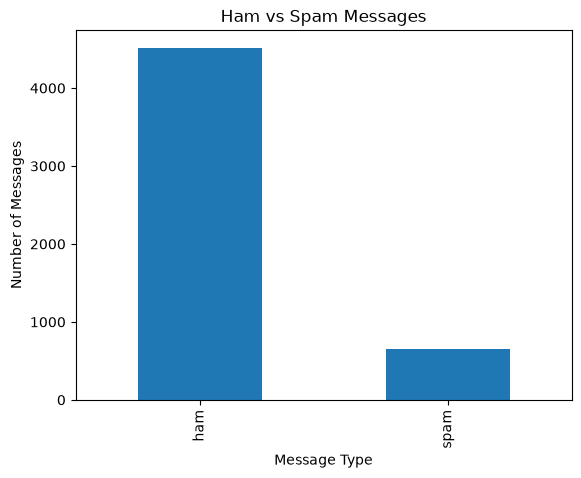

In [9]:
df["label"].value_counts().plot(kind="bar")
plt.title("Ham vs Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

## 3. Text preprocessing

The cleaning function:
- converts text to lowercase
- removes URLs
- removes numbers
- removes punctuation
- tokenizes words
- removes English stop words
- lemmatizes words

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


## 4. Split the data into training and testing sets

In [11]:
X = df["clean_message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


## 5. Convert text into numbers using TF-IDF

In [12]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 6911)
Testing TF-IDF shape: (1034, 6911)


## 6. Train the model

In [13]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Model training completed.")

Model training completed.


## 7. Evaluate the model

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy percentage: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

Accuracy: 0.9662
Accuracy percentage: 96.62%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.73      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



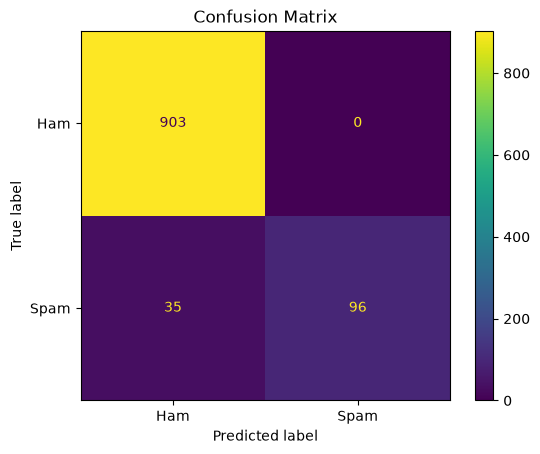

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## 8. Create the final connected pipeline

In [16]:
final_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

print("Final pipeline accuracy:",
      f"{accuracy_score(y_test, final_predictions) * 100:.2f}%")

Final pipeline accuracy: 96.62%


## 9. Save the trained model

This is the connection between the notebook and the website.

The notebook creates:

`models/sms_spam_model.pkl`

The website loads that exact file.

In [19]:
MODEL_PATH = Path("models/sms_spam_model.pkl")
joblib.dump(final_model, MODEL_PATH)

print("Saved model to:", MODEL_PATH)

Saved model to: models\sms_spam_model.pkl


## 10. Test new messages

In [18]:
test_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we still meeting tomorrow?",
    "URGENT! You have won $1000. Claim your reward now!",
    "Can you send me the notes from today's class?"
]

predictions = final_model.predict(test_messages)

for message, prediction in zip(test_messages, predictions):
    result = "SPAM" if prediction == 1 else "HAM"
    print("Message:", message)
    print("Prediction:", result)
    print("-" * 60)

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM
------------------------------------------------------------
Message: Hey, are we still meeting tomorrow?
Prediction: HAM
------------------------------------------------------------
Message: URGENT! You have won $1000. Claim your reward now!
Prediction: SPAM
------------------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: HAM
------------------------------------------------------------


## Conclusion

The project completes an NLP text-classification workflow:

**SMS → Cleaning → TF-IDF → Naive Bayes → Evaluation → Saved Model → Web App**

The saved model is reused by the website.